In [2]:
# Cell 1: imports
import gzip
import itertools
import numpy as np
import matplotlib.pyplot as plt


In [3]:
# Cell 2: load the edge list from a gzipped text file
# NOTE: change the path to your file, e.g., "amazon0302.txt.gz"
path = "email-Enron.txt.gz"  # <-- replace with your filename

with gzip.open(path, "rt") as f:
    data = [row for row in f if not row.startswith("#")]
    mydata = [tuple(int(x) for x in row.split()) for row in data]  # (i, j) per line

# peek
mydata[:5]


[(0, 1), (1, 0), (1, 2), (1, 3), (1, 4)]

In [4]:
# Cell 3: number of unique nodes and the maximum node id
num_unique = len(set(itertools.chain.from_iterable(mydata)))
max_id = max(set(itertools.chain.from_iterable(mydata)))
num_unique, max_id


(36692, 36691)

In [5]:
# Cell 4: set N (nodes assumed labeled from 0..max_id)
N = max_id + 1
N


36692

In [6]:
N = 5000

In [7]:
# Cell 5: build a dense adjacency matrix (uint8 to save RAM)
A = np.zeros((N, N), dtype=np.uint8)
for i, j in mydata:
    if i<N and j<N:
        A[i, j] = 1
# If the graph is undirected and the file lists only one direction, uncomment:
# for i, j in mydata:
#     A[j, i] = 1


In [8]:
# Cell 6: quick symmetry check (for undirected graphs)
(A.T == A).all()


np.True_

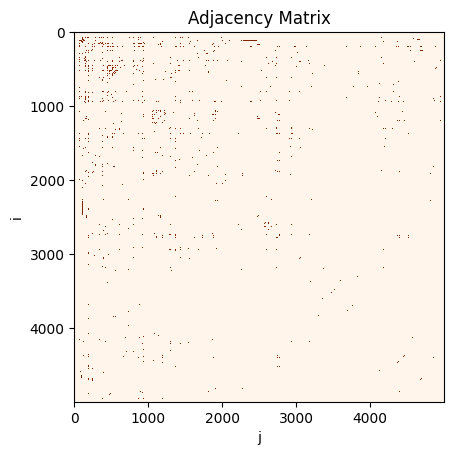

In [9]:
# Cell 7: visualize the adjacency matrix
fig, ax = plt.subplots()
ax.imshow(A, cmap="Oranges", interpolation="nearest")
ax.set_aspect("equal")
ax.set_title("Adjacency Matrix")
ax.set_xlabel("j")
ax.set_ylabel("i")
plt.show()


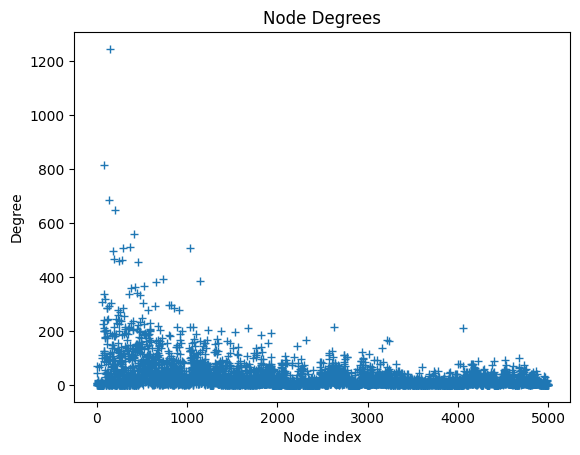

In [12]:
degrees = A.sum(axis=1)
plt.figure()
plt.plot(degrees,'+')
plt.xlabel("Node index")
plt.ylabel("Degree")
plt.title("Node Degrees")
plt.show()

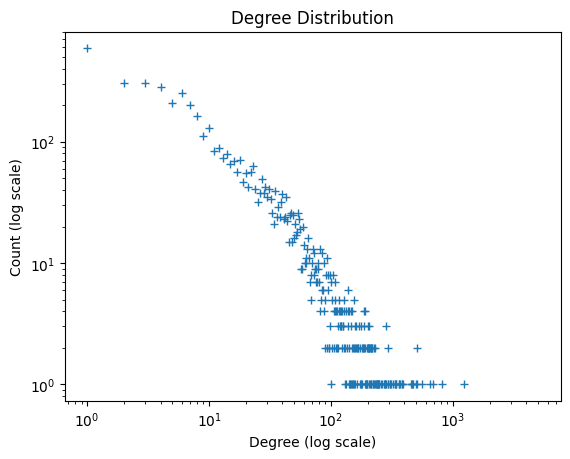

In [17]:
d = np.arange(0, N)
c = np.bincount(degrees, minlength=N)
fig, ax = plt.subplots()
ax.plot(d,c,'+')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel("Degree (log scale)")
ax.set_ylabel("Count (log scale)")
ax.set_title("Degree Distribution")
plt.show()